# Imports and Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score

# Models
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from catboost import CatBoostClassifier, Pool

# Utilities
from scipy.stats import rankdata
import gc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
COMP_PATH = "/kaggle/input/playground-series-s5e5"
ORIG_PATH = "/kaggle/input/f1-strategy-dataset-pit-stop-prediction"

TRAIN_PATH  = os.path.join(COMP_PATH, "train.csv")
TEST_PATH   = os.path.join(COMP_PATH, "test.csv")
SUB_PATH    = os.path.join(COMP_PATH, "sample_submission.csv")
ORIG_PATH_F = os.path.join(ORIG_PATH, "f1_strategy_dataset_v4.csv")

# Cross-Validation Config
N_FOLDS     = 5          # GroupKFold splits
TARGET      = "PitNextLap"
ORIG_WEIGHT = 0.7        # Sample weight for original dataset rows (discounted)

# Compound Ordinal Map (durability order)
# Softer compounds degrade faster → lower laps before pit
COMPOUND_ORDER = {
    "WET"          : 0,
    "INTERMEDIATE" : 1,
    "SOFT"         : 2,
    "MEDIUM"       : 3,
    "HARD"         : 4,
}

# LightGBM Params (starting point)
LGB_PARAMS = {
    "objective"        : "binary",
    "metric"           : "auc",
    "learning_rate"    : 0.02,  
    "num_leaves"       : 255,  
    "max_depth"        : -1,
    "min_child_samples": 100,  
    "feature_fraction" : 0.7,   
    "bagging_fraction" : 0.7,   
    "bagging_freq"     : 1,
    "lambda_l1"        : 0.2,    
    "lambda_l2"        : 0.2,     
    "verbose"          : -1,
    "seed"             : SEED,
    "n_jobs"           : -1,
}

# XGBoost Params
XGB_PARAMS = {
    "objective"        : "binary:logistic",
    "eval_metric"      : "auc",
    "learning_rate"    : 0.05,
    "max_depth"        : 7,
    "min_child_weight" : 50,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.1,
    "seed"             : SEED,
    "tree_method"      : "hist",
    "device"           : "cpu",
}

# CatBoost Params
CB_PARAMS = {
    "iterations"       : 2000,
    "learning_rate"    : 0.05,
    "depth"            : 7,
    "eval_metric"      : "AUC",
    "random_seed"      : SEED,
    "early_stopping_rounds": 100,
    "verbose"          : 200,
    "task_type"        : "CPU",
}

print("All imports loaded successfully.")
print(f"   LightGBM  v{lgb.__version__}")
print(f"   XGBoost   v{xgb.__version__}")
print(f"   CatBoost  v{cb.__version__}")

All imports loaded successfully.
   LightGBM  v4.6.0
   XGBoost   v3.2.0
   CatBoost  v1.2.10


# Load Data + Merge Original

In [2]:
# Load Competition Files
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv')

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")

# Load Original Dataset
orig = pd.read_csv('/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv')
print(f"Orig  shape (raw) : {orig.shape}")

# Align Original to Competition Schema
orig.drop(columns=["Normalized_TyreLife"], inplace=True, errors="ignore")
orig["id"] = -1
orig = orig[[c for c in train.columns if c in orig.columns]]

# Compound has NaN rows — drop them, then cast to str
print(f"\nOrig nulls before clean :\n{orig.isnull().sum()[orig.isnull().sum() > 0]}")

orig.dropna(subset=["Compound"], inplace=True)
orig["Compound"] = orig["Compound"].astype(str).str.strip().str.upper()

# Cast all string columns to consistent str type
for col in ["Driver", "Race", "Compound"]:
    orig[col]  = orig[col].astype(str).str.strip()
    train[col] = train[col].astype(str).str.strip()
    test[col]  = test[col].astype(str).str.strip()

print(f"Orig  shape (clean) : {orig.shape}")

print(f"\nCompound values — Train : {sorted(train['Compound'].unique())}")
print(f"Compound values — Orig  : {sorted(orig['Compound'].unique())}")
print(f"\nYear range — Train : {train['Year'].min()}–{train['Year'].max()}")
print(f"Year range — Orig  : {orig['Year'].min()}–{orig['Year'].max()}")

print("\n── Target Distribution ──")
print(f"  Train : {train[TARGET].value_counts(normalize=True).round(3).to_dict()}")
print(f"  Orig  : {orig[TARGET].value_counts(normalize=True).round(3).to_dict()}")

train["is_orig"] = 0
orig["is_orig"]  = 1

# Combine Train + Original
all_train = pd.concat([train, orig], axis=0, ignore_index=True)

print(f"\nCombined train shape  : {all_train.shape}")
print(f"Competition rows : {(all_train['is_orig']==0).sum():,}")
print(f"Original rows    : {(all_train['is_orig']==1).sum():,}")

all_train["sample_weight"] = np.where(
    all_train["is_orig"] == 1, ORIG_WEIGHT, 1.0
)

print(f"\nMissing values in all_train : {all_train.isnull().sum().sum()}")
print(f"Missing values in test      : {test.isnull().sum().sum()}")

print("\nData loaded and merged successfully.")

Train shape : (439140, 16)
Test  shape : (188165, 15)
Orig  shape (raw) : (101371, 16)

Orig nulls before clean :
Compound    66
dtype: int64
Orig  shape (clean) : (101305, 16)

Compound values — Train : ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']
Compound values — Orig  : ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']

Year range — Train : 2022–2025
Year range — Orig  : 2022–2025

── Target Distribution ──
  Train : {0.0: 0.801, 1.0: 0.199}
  Orig  : {0: 0.745, 1: 0.255}

Combined train shape  : (540445, 17)
Competition rows : 439,140
Original rows    : 101,305

Missing values in all_train : 0
Missing values in test      : 0

Data loaded and merged successfully.


In [3]:
#  PSEUDO LABELING
v4_preds = pd.read_csv("/kaggle/input/datasets/shamanthakreddymallu/my-v4-submission/submission.csv")

# Merge predictions onto test set
test_with_preds = test.merge(v4_preds, on="id")
print(f"Test rows          : {len(test_with_preds)}")

HIGH_CONF_PIT    = 0.90   # very likely pitting
LOW_CONF_PIT     = 0.04   # very likely NOT pitting

mask_pit    = test_with_preds["PitNextLap"] >= HIGH_CONF_PIT
mask_nopit  = test_with_preds["PitNextLap"] <= LOW_CONF_PIT

pseudo_pit   = test_with_preds[mask_pit].copy()
pseudo_nopit = test_with_preds[mask_nopit].copy()

print(f"\nHigh confidence PIT rows    : {len(pseudo_pit):,}  (prob >= {HIGH_CONF_PIT})")
print(f"High confidence NO-PIT rows : {len(pseudo_nopit):,}  (prob <= {LOW_CONF_PIT})")

# Assign hard labels
pseudo_pit["PitNextLap"]   = 1.0
pseudo_nopit["PitNextLap"] = 0.0

# ddCombine
pseudo_all = pd.concat([pseudo_pit, pseudo_nopit], axis=0)
pseudo_all["is_orig"]       = 0
pseudo_all["sample_weight"] = 0.6   # discounted — not real labels

print(f"Total pseudo rows           : {len(pseudo_all):,}")
print(f"Pseudo pit rate             : {pseudo_all['PitNextLap'].mean():.3f}")

# all_train already has competition + original rows from Cell 2
all_train = pd.concat([all_train, pseudo_all], axis=0, ignore_index=True)

print(f"\nCombined training set:")
print(f"  Competition rows : {(all_train['is_orig']==0).sum():,}")
print(f"  Original rows    : {(all_train['is_orig']==1).sum():,}")
print(f"  Pseudo rows      : {len(pseudo_all):,}")
print(f"  Total            : {len(all_train):,}")
print(f"\n Pseudo-labeling complete")

Test rows          : 188165

High confidence PIT rows    : 18,764  (prob >= 0.9)
High confidence NO-PIT rows : 5,788  (prob <= 0.04)
Total pseudo rows           : 24,552
Pseudo pit rate             : 0.764

Combined training set:
  Competition rows : 463,692
  Original rows    : 101,305
  Pseudo rows      : 24,552
  Total            : 564,997

 Pseudo-labeling complete


# Feature Engineering

In [4]:
# Mark test rows, concat
test["is_orig"]       = 0
test["sample_weight"] = 1.0
test[TARGET]          = np.nan

combined = pd.concat([all_train, test], axis=0, ignore_index=True)
print(f"Combined (train+test) shape: {combined.shape}")

Combined (train+test) shape: (753162, 18)


## Compound Ordinal Encoding

In [5]:
combined["Compound_ord"] = combined["Compound"].map(COMPOUND_ORDER)

## Race + Year Group Key

In [6]:
combined["RaceYear"] = combined["Race"] + "_" + combined["Year"].astype(str)

## Total Laps per Race (derived from RaceProgress)

In [7]:
combined["TotalLaps_est"] = (
    combined["LapNumber"] / combined["RaceProgress"].replace(0, np.nan)
).round()

combined["LapsRemaining"] = combined["TotalLaps_est"] - combined["LapNumber"]

## Tyre × Compound Interaction

In [8]:
# 15 laps on SOFT ≠ 15 laps on HARD
combined["TyreLife_x_Compound"] = combined["TyreLife"] * combined["Compound_ord"]

# Expected max stint length per compound (domain knowledge)
COMPOUND_MAX_STINT = {
    "SOFT"         : 25,
    "MEDIUM"       : 35,
    "HARD"         : 50,
    "INTERMEDIATE" : 30,
    "WET"          : 40,
}
combined["MaxStint"] = combined["Compound"].map(COMPOUND_MAX_STINT)
combined["TyrePct_Used"] = combined["TyreLife"] / combined["MaxStint"]  # 0→1+ scale
combined["TyrePct_Used"] = combined["TyrePct_Used"].clip(0, 2)          # cap outliers

## Race Stage Flags

In [9]:
combined["IsEarlyRace"]  = (combined["RaceProgress"] < 0.25).astype(int)
combined["IsMidRace"]    = ((combined["RaceProgress"] >= 0.25) &
                            (combined["RaceProgress"] < 0.70)).astype(int)
combined["IsLateRace"]   = (combined["RaceProgress"] >= 0.70).astype(int)

# Undercut window: laps 20-40% and 55-75% are classic pit windows
combined["InPitWindow"]  = (
    ((combined["RaceProgress"] >= 0.20) & (combined["RaceProgress"] <= 0.40)) |
    ((combined["RaceProgress"] >= 0.55) & (combined["RaceProgress"] <= 0.75))
).astype(int)

## Stint Number as Pit Count Proxy

In [10]:
combined["StopsAlready"]   = combined["Stint"] - 1
combined["Is1Stopper"]     = (combined["Stint"] == 1).astype(int)  # likely to pit once more# 

## Interaction Features

In [11]:
# Old tyres + late race = THE core pit trigger
combined["TyreLife_x_RaceProgress"] = (
    combined["TyreLife"] * combined["RaceProgress"]
)

# How fast are tyres degrading per lap?
combined["Degradation_per_Lap"] = (
    combined["Cumulative_Degradation"] / combined["TyreLife"].replace(0, 1)
).clip(0, 10)

# Strategic ratio: can we physically make it to the end?
combined["TyreLife_vs_LapsRemaining"] = (
    combined["TyreLife"] / combined["LapsRemaining"].replace(0, 1)
).clip(0, 10)

# Binary: tyres last longer than laps remaining → no pit needed
combined["CanMakeItToEnd"] = (
    combined["TyreLife"] >= combined["LapsRemaining"]
).astype(int)

# Stint aggression: high stint number on soft compound = dangerous
combined["Stint_x_Compound"] = combined["Stint"] * combined["Compound_ord"]

# Raw distance to optimal stint end
combined["LapsOverMaxStint"] = (
    combined["TyreLife"] - combined["MaxStint"]
).clip(-50, 50)

## Group-Based Rolling Features

In [12]:
# Sort by driver + race + lap so rolling windows are temporal
combined.sort_values(["Driver", "RaceYear", "LapNumber"], inplace=True)
combined.reset_index(drop=True, inplace=True)

grp = combined.groupby(["Driver", "RaceYear"])

# Rolling 3-lap mean of LapTime — smoothed pace
combined["LapTime_roll3"]  = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling 3-lap mean of LapTime_Delta — degradation trend
combined["Delta_roll3"]    = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling 3-lap mean of Cumulative_Degradation
combined["CumDeg_roll3"]   = (
    grp["Cumulative_Degradation"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Lap-over-lap LapTime change (sudden slowdown = tyre cliff)
combined["LapTime_diff1"]  = (
    grp["LapTime (s)"].transform(lambda x: x.diff(1))
)

## Extended Rolling Windows

In [13]:
combined["LapTime_roll5"]  = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(5,  min_periods=1).mean())
)
combined["Delta_roll5"]    = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(5,  min_periods=1).mean())
)
combined["LapTime_roll10"] = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(10, min_periods=1).mean())
)
combined["Delta_roll10"]   = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(10, min_periods=1).mean())
)

# Pace dropoff: recent 3-lap avg vs longer 10-lap avg
# Positive value = getting slower = tyre cliff signal
combined["PaceDropoff_3v10"] = (
    combined["LapTime_roll3"] - combined["LapTime_roll10"]
)
combined["DegDropoff_3v10"]  = (
    combined["Delta_roll3"] - combined["Delta_roll10"]
)

## Position-Based Features

In [14]:
combined["InPoints"]        = (combined["Position"] <= 10).astype(int)
combined["TopFive"]         = (combined["Position"] <= 5).astype(int)
combined["Position_x_Lap"]  = combined["Position"] * combined["RaceProgress"]

## Target Encoding

In [15]:
TARGET_ENC_COLS = ["Driver", "Race", "RaceYear", "Compound"]
SMOOTH          = 20

comp_train_mask = combined[TARGET].notna()
global_mean     = combined.loc[comp_train_mask, TARGET].mean()

for col in TARGET_ENC_COLS:
    agg = (
        combined.loc[comp_train_mask]
        .groupby(col)[TARGET]
        .agg(["mean", "count"])
    )
    agg.columns = ["te_mean", "te_count"]
    agg["te_smooth"] = (
        (agg["te_count"] * agg["te_mean"] + SMOOTH * global_mean)
        / (agg["te_count"] + SMOOTH)
    )
    combined[f"TE_{col}"] = (
        combined[col].map(agg["te_smooth"]).fillna(global_mean)
    )

print(f"Target encoding done — global mean: {global_mean:.4f}")
print("Encoded:", [f"TE_{c}" for c in TARGET_ENC_COLS])

Target encoding done — global mean: 0.2335
Encoded: ['TE_Driver', 'TE_Race', 'TE_RaceYear', 'TE_Compound']


## Label Encoding for Categorical Columns

In [16]:
LE_COLS = ["Driver", "Race", "Compound", "RaceYear"]
le_dict = {}
for col in LE_COLS:
    le = LabelEncoder()
    combined[f"LE_{col}"] = le.fit_transform(combined[col].astype(str))
    le_dict[col] = le

print("Label encoding done for:", [f"LE_{c}" for c in LE_COLS])

Label encoding done for: ['LE_Driver', 'LE_Race', 'LE_Compound', 'LE_RaceYear']


## Fill any NaNs created by rolling/diff

In [17]:
roll_cols = [
    "LapTime_roll3", "Delta_roll3", "CumDeg_roll3", "LapTime_diff1",
    "LapTime_roll5", "Delta_roll5", "LapTime_roll10", "Delta_roll10",
    "PaceDropoff_3v10", "DegDropoff_3v10",
    "TotalLaps_est", "LapsRemaining",
    "Degradation_per_Lap", "TyreLife_vs_LapsRemaining",
    "LapsOverMaxStint"]

combined[roll_cols] = combined[roll_cols].fillna(0)

## Final Features

In [18]:
FEATURES = [
    # Raw numerics
    "Year", "LapNumber", "Stint", "TyreLife", "Position",
    "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation",
    "RaceProgress", "Position_Change", "PitStop",
    # Tyre features
    "Compound_ord", "TyreLife_x_Compound", "TyrePct_Used", "MaxStint",
    "TotalLaps_est", "LapsRemaining",
    # Interaction features
    "TyreLife_x_RaceProgress", "Degradation_per_Lap",
    "TyreLife_vs_LapsRemaining", "CanMakeItToEnd",
    "Stint_x_Compound", "LapsOverMaxStint",
    # Race stage
    "IsEarlyRace", "IsMidRace", "IsLateRace", "InPitWindow",
    "StopsAlready", "Is1Stopper",
    # Rolling windows
    "LapTime_roll3", "Delta_roll3", "CumDeg_roll3", "LapTime_diff1",
    "LapTime_roll5", "Delta_roll5",
    "LapTime_roll10", "Delta_roll10",
    "PaceDropoff_3v10", "DegDropoff_3v10",
    # Position
    "InPoints", "TopFive", "Position_x_Lap",
    # Encodings
    "LE_Driver", "LE_Race", "LE_Compound", "LE_RaceYear",
    "TE_Driver", "TE_Race", "TE_Compound", "TE_RaceYear",
]  

print(f"\nTotal features: {len(FEATURES)}")


Total features: 50


## Split back into train / test

In [19]:
train_fe = combined[combined[TARGET].notna()].copy()
test_fe  = combined[combined[TARGET].isna()].copy()

print(f"\ntrain_fe shape : {train_fe.shape}")
print(f"test_fe  shape : {test_fe.shape}")

# Quick feature null check
null_check = train_fe[FEATURES].isnull().sum()
if null_check.sum() == 0:
    print("\nNo nulls in feature matrix.")
else:
    print("\nNulls found:")
    print(null_check[null_check > 0])


train_fe shape : (564997, 58)
test_fe  shape : (188165, 58)

No nulls in feature matrix.


## Hyperparameters Search

Starting Optuna search — 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]


  Best trial AUC : 0.92722
  Best params:
    learning_rate            : 0.04625621093516738
    num_leaves               : 86
    max_depth                : 10
    min_child_samples        : 181
    feature_fraction         : 0.7215036116333746
    bagging_fraction         : 0.9711753504396902
    bagging_freq             : 6
    lambda_l1                : 1.716705604097293e-08
    lambda_l2                : 0.004214123131007914
    min_gain_to_split        : 0.04268656502677522

LGB_PARAMS_OPTUNA ready


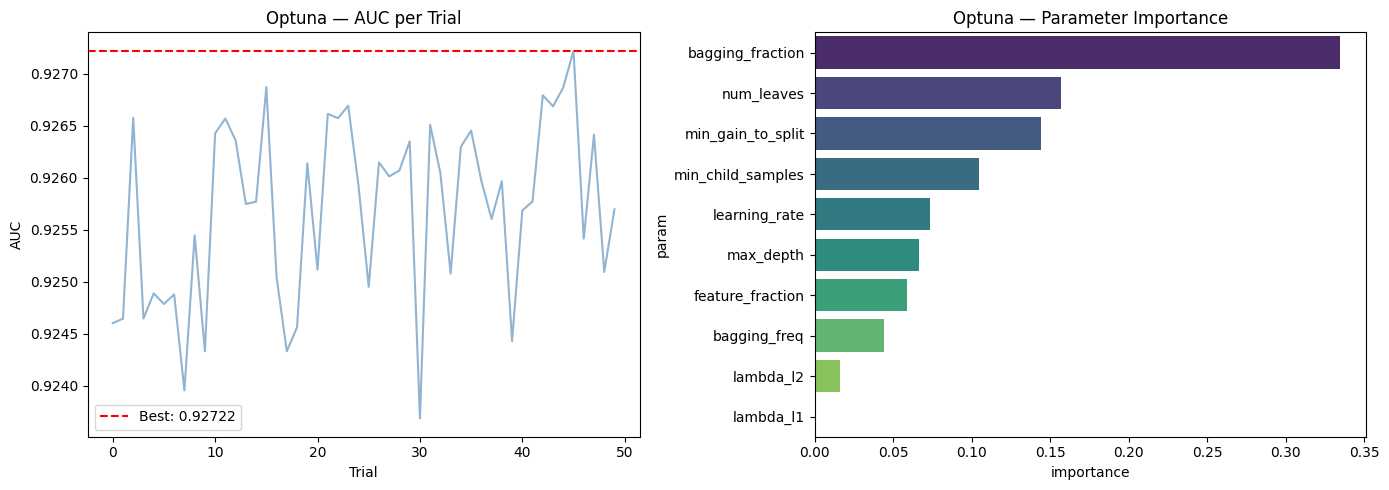

In [20]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

X      = train_fe[FEATURES].values
y      = train_fe[TARGET].values.astype(int)
w      = train_fe["sample_weight"].values
groups = train_fe["RaceYear"].values
X_test = test_fe[FEATURES].values

gkf = GroupKFold(n_splits=N_FOLDS)

first_fold_splits  = list(gkf.split(X, y, groups))
tr_idx_opt, val_idx_opt = first_fold_splits[0]

X_tr_opt  = X[tr_idx_opt]
X_val_opt = X[val_idx_opt]
y_tr_opt  = y[tr_idx_opt]
y_val_opt = y[val_idx_opt]
w_tr_opt  = w[tr_idx_opt]

def make_datasets():
    dtrain = lgb.Dataset(
        X_tr_opt, label=y_tr_opt,
        weight=w_tr_opt, feature_name=FEATURES,
        free_raw_data=False,
    )
    dvalid = lgb.Dataset(
        X_val_opt, label=y_val_opt,
        feature_name=FEATURES, reference=dtrain,
        free_raw_data=False,
    )
    return dtrain, dvalid

def objective(trial):
    params = {
        "objective"          : "binary",
        "metric"             : "auc",
        "verbosity"          : -1,
        "seed"               : SEED,
        "n_jobs"             : -1,
        "feature_pre_filter" : False,
        "learning_rate"      : trial.suggest_float(
                                  "learning_rate", 0.01, 0.05, log=True),
        "num_leaves"         : trial.suggest_int(
                                  "num_leaves", 63, 511),
        "max_depth"          : trial.suggest_int(
                                  "max_depth", 5, 12),
        "min_child_samples"  : trial.suggest_int(
                                  "min_child_samples", 50, 300),
        "feature_fraction"   : trial.suggest_float(
                                  "feature_fraction", 0.5, 1.0),
        "bagging_fraction"   : trial.suggest_float(
                                  "bagging_fraction", 0.5, 1.0),
        "bagging_freq"       : trial.suggest_int(
                                  "bagging_freq", 1, 7),
        "lambda_l1"          : trial.suggest_float(
                                  "lambda_l1", 1e-8, 1.0, log=True),
        "lambda_l2"          : trial.suggest_float(
                                  "lambda_l2", 1e-8, 1.0, log=True),
        "min_gain_to_split"  : trial.suggest_float(
                                  "min_gain_to_split", 0.0, 1.0),
    }

    dtrain_opt, dvalid_opt = make_datasets()

    model = lgb.train(
        params,
        dtrain_opt,
        num_boost_round = 8000,
        valid_sets      = [dvalid_opt],
        callbacks       = [
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    auc = roc_auc_score(y_val_opt, model.predict(X_val_opt))
    return auc

print("Starting Optuna search — 50 trials...")

study = optuna.create_study(
    direction = "maximize",
    sampler   = TPESampler(seed=SEED),
)
study.optimize(
    objective,
    n_trials          = 50,
    show_progress_bar = True,
    catch             = (Exception,),
)

print(f"\n{'='*60}")
print(f"  Best trial AUC : {study.best_value:.5f}")
print(f"  Best params:")
for k, v in study.best_params.items():
    print(f"    {k:25s}: {v}")
print(f"{'='*60}")

LGB_PARAMS_OPTUNA = {
    "objective"          : "binary",
    "metric"             : "auc",
    "verbose"            : -1,
    "seed"               : SEED,
    "n_jobs"             : -1,
    "feature_pre_filter" : False,
    **study.best_params,
}

print("\nLGB_PARAMS_OPTUNA ready")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
trial_aucs = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_aucs, alpha=0.6, color="steelblue")
axes[0].axhline(
    study.best_value, color="red",
    linestyle="--", label=f"Best: {study.best_value:.5f}"
)
axes[0].set_title("Optuna — AUC per Trial")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("AUC")
axes[0].legend()

# Parameter importance
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame(
        list(importances.items()),
        columns=["param", "importance"]
    ).sort_values("importance", ascending=False)
    sns.barplot(data=imp_df, x="importance", y="param",
                palette="viridis", ax=axes[1])
    axes[1].set_title("Optuna — Parameter Importance")
except Exception as e:
    axes[1].set_title(f"Parameter importance unavailable: {e}")

plt.tight_layout()
plt.show()

# Cross-validation + LightGBM

  LightGBM — 5-Fold GroupKFold (by Year — one season per fold)
[500]	valid_0's auc: 0.926336
[1000]	valid_0's auc: 0.927087

  Fold 1 │ AUC: 0.92722 │ Best iter: 858
[500]	valid_0's auc: 0.937323
[1000]	valid_0's auc: 0.937929

  Fold 2 │ AUC: 0.93811 │ Best iter: 1132
[500]	valid_0's auc: 0.932869
[1000]	valid_0's auc: 0.933318

  Fold 3 │ AUC: 0.93339 │ Best iter: 1164

  Fold 4 │ AUC: 0.94454 │ Best iter: 317
[500]	valid_0's auc: 0.960151

  Fold 5 │ AUC: 0.96016 │ Best iter: 504

  LightGBM OOF AUC : 0.94076
  Per-fold AUCs    : [np.float64(0.92722), np.float64(0.93811), np.float64(0.93339), np.float64(0.94454), np.float64(0.96016)]
  Std dev          : 0.01127


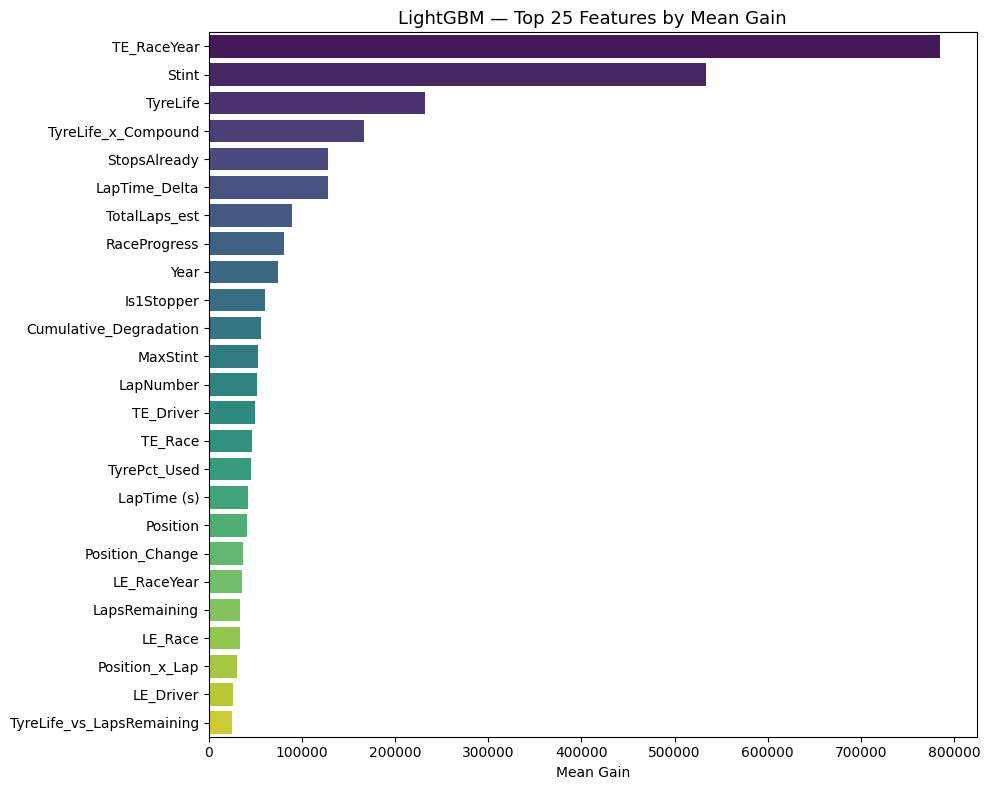


LightGBM training complete.
   OOF array  shape : (564997,)
   Test preds shape : (188165,)


In [21]:
from lightgbm import early_stopping, log_evaluation

X      = train_fe[FEATURES].values
y      = train_fe[TARGET].values.astype(int)
w      = train_fe["sample_weight"].values
groups = train_fe["RaceYear"].values 

X_test = test_fe[FEATURES].values

oof_lgb  = np.zeros(len(X))                  # out-of-fold predictions
test_lgb = np.zeros(len(X_test))             # averaged test predictions
fold_auc = []
feature_importance_list = []

gkf = GroupKFold(n_splits=N_FOLDS)

print("=" * 60)
print(f"  LightGBM — {N_FOLDS}-Fold GroupKFold (by Year — one season per fold)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):

    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr        = w[tr_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=w_tr,
                         feature_name=FEATURES)
    dvalid = lgb.Dataset(X_val, label=y_val,
                         feature_name=FEATURES, reference=dtrain)

    model = lgb.train(
        LGB_PARAMS_OPTUNA,    # use Optuna params instead
        dtrain,
        num_boost_round        = 8000,
        valid_sets             = [dvalid],
        callbacks              = [
            early_stopping(stopping_rounds=150, verbose=False),
            log_evaluation(period=500),
        ],
    )

    oof_lgb[val_idx] = model.predict(X_val)
    test_lgb += model.predict(X_test) / N_FOLDS

    auc = roc_auc_score(y_val, oof_lgb[val_idx])
    fold_auc.append(auc)
    print(f"\n  Fold {fold} │ AUC: {auc:.5f} │ "
          f"Best iter: {model.best_iteration}")

    fi = pd.DataFrame({
        "feature"   : FEATURES,
        "importance": model.feature_importance(importance_type="gain"),
        "fold"      : fold,
    })
    feature_importance_list.append(fi)

    del X_tr, X_val, y_tr, y_val, dtrain, dvalid
    gc.collect()

oof_auc_lgb = roc_auc_score(y, oof_lgb)

print("\n" + "=" * 60)
print(f"  LightGBM OOF AUC : {oof_auc_lgb:.5f}")
print(f"  Per-fold AUCs    : {[round(a,5) for a in fold_auc]}")
print(f"  Std dev          : {np.std(fold_auc):.5f}")
print("=" * 60)

# Feature Importance Plot
fi_df = (
    pd.concat(feature_importance_list)
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df.head(25), x="importance", y="feature",
            palette="viridis")
plt.title("LightGBM — Top 25 Features by Mean Gain", fontsize=13)
plt.xlabel("Mean Gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nLightGBM training complete.")
print(f"   OOF array  shape : {oof_lgb.shape}")
print(f"   Test preds shape : {test_lgb.shape}")

# XGBoost

  XGBoost — 5-Fold GroupKFold (by Year — one season per fold)
[0]	val-auc:0.89727
[200]	val-auc:0.92111
[400]	val-auc:0.92335
[600]	val-auc:0.92438
[800]	val-auc:0.92491
[1000]	val-auc:0.92483
[1023]	val-auc:0.92489

  Fold 1 │ AUC: 0.92489 │ Best iter: 923
[0]	val-auc:0.91396
[200]	val-auc:0.93449
[400]	val-auc:0.93619
[600]	val-auc:0.93682
[800]	val-auc:0.93722
[1000]	val-auc:0.93727
[1029]	val-auc:0.93729

  Fold 2 │ AUC: 0.93729 │ Best iter: 929
[0]	val-auc:0.89787
[200]	val-auc:0.92728
[400]	val-auc:0.92941
[600]	val-auc:0.93029
[784]	val-auc:0.93039

  Fold 3 │ AUC: 0.93039 │ Best iter: 684
[0]	val-auc:0.92234
[200]	val-auc:0.94266
[400]	val-auc:0.94362
[560]	val-auc:0.94366

  Fold 4 │ AUC: 0.94366 │ Best iter: 460
[0]	val-auc:0.94034
[200]	val-auc:0.95787
[400]	val-auc:0.95894
[600]	val-auc:0.95924
[800]	val-auc:0.95939
[1000]	val-auc:0.95953
[1200]	val-auc:0.95957
[1265]	val-auc:0.95951

  Fold 5 │ AUC: 0.95951 │ Best iter: 1165

  XGBoost OOF AUC : 0.93944
  Per-fold AUCs   :

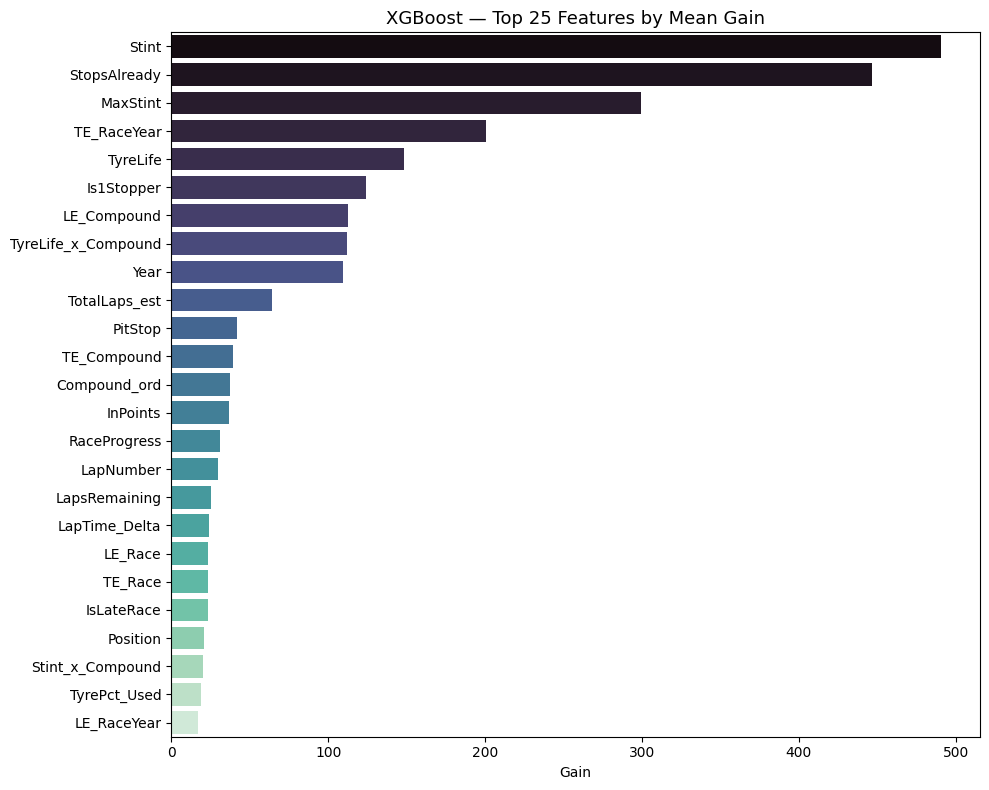


XGBoost training complete.
   OOF array  shape : (564997,)
   Test preds shape : (188165,)


In [22]:
oof_xgb  = np.zeros(len(X))
test_xgb = np.zeros(len(X_test))
fold_auc_xgb = []

print("=" * 60)
print(f"  XGBoost — {N_FOLDS}-Fold GroupKFold (by Year — one season per fold)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):

    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr        = w[tr_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr,
                         feature_names=FEATURES)
    dvalid = xgb.DMatrix(X_val, label=y_val,
                         feature_names=FEATURES)
    dtest  = xgb.DMatrix(X_test, feature_names=FEATURES)

    model = xgb.train(
        XGB_PARAMS,
        dtrain,
        num_boost_round      = 3000,
        evals                = [(dvalid, "val")],
        early_stopping_rounds= 100,
        verbose_eval         = 200,
    )

    oof_xgb[val_idx]  = model.predict(dvalid)
    test_xgb         += model.predict(dtest) / N_FOLDS

    auc = roc_auc_score(y_val, oof_xgb[val_idx])
    fold_auc_xgb.append(auc)
    print(f"\n  Fold {fold} │ AUC: {auc:.5f} │ "
          f"Best iter: {model.best_iteration}")

    del X_tr, X_val, y_tr, y_val, dtrain, dvalid, dtest
    gc.collect()

# OOF Score
oof_auc_xgb = roc_auc_score(y, oof_xgb)

print("\n" + "=" * 60)
print(f"  XGBoost OOF AUC : {oof_auc_xgb:.5f}")
print(f"  Per-fold AUCs   : {[round(a,5) for a in fold_auc_xgb]}")
print(f"  Std dev         : {np.std(fold_auc_xgb):.5f}")
print("=" * 60)

# Feature Importance Plot
fi_xgb = (
    pd.Series(model.get_score(importance_type="gain"))
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
)
fi_xgb.columns = ["feature", "importance"]

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_xgb, x="importance", y="feature", palette="mako")
plt.title("XGBoost — Top 25 Features by Mean Gain", fontsize=13)
plt.xlabel("Gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nXGBoost training complete.")
print(f"   OOF array  shape : {oof_xgb.shape}")
print(f"   Test preds shape : {test_xgb.shape}")

# CatBoost

  CatBoost — 5-Fold GroupKFold (by Year — one season per fold)
  Cat features: ['LE_Driver', 'LE_Race', 'LE_Compound', 'LE_RaceYear']
0:	test: 0.8649182	best: 0.8649182 (0)	total: 562ms	remaining: 18m 42s
200:	test: 0.9117730	best: 0.9118399 (199)	total: 1m 21s	remaining: 12m 11s
400:	test: 0.9156516	best: 0.9158094 (371)	total: 2m 42s	remaining: 10m 49s
600:	test: 0.9166607	best: 0.9167077 (596)	total: 4m 4s	remaining: 9m 30s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9172088378
bestIteration = 677

Shrink model to first 678 iterations.

  Fold 1 │ AUC: 0.91721 │ Best iter: 677
0:	test: 0.9035177	best: 0.9035177 (0)	total: 431ms	remaining: 14m 21s
200:	test: 0.9188165	best: 0.9188165 (200)	total: 1m 22s	remaining: 12m 20s
400:	test: 0.9222668	best: 0.9222720 (396)	total: 2m 44s	remaining: 10m 56s
600:	test: 0.9232146	best: 0.9232333 (593)	total: 4m 6s	remaining: 9m 33s
800:	test: 0.9241720	best: 0.9242770 (757)	total: 5m 26s	remaining: 8m 8s
1000:	test: 0.924

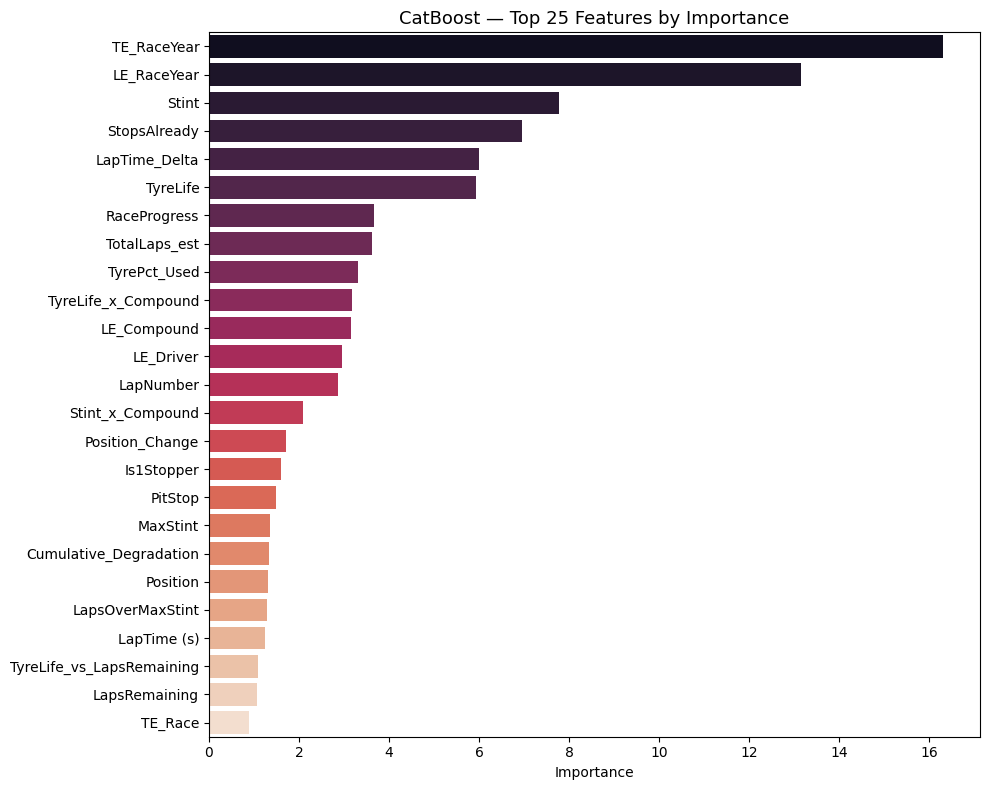


CatBoost training complete.
   OOF array  shape : (564997,)
   Test preds shape : (188165,)


In [23]:
# CatBoost rejects cat_features on float numpy arrays;
# passing a DataFrame lets it inspect column types correctly.
X_df      = train_fe[FEATURES].copy()
X_test_df = test_fe[FEATURES].copy()

# Cast LE columns to int (they're integers but may be stored as float)
LE_COLS_IN_FEATURES = ["LE_Driver", "LE_Race", "LE_Compound", "LE_RaceYear"]
for col in LE_COLS_IN_FEATURES:
    X_df[col]      = X_df[col].astype(int)
    X_test_df[col] = X_test_df[col].astype(int)

y_arr = train_fe[TARGET].values.astype(int)
w_arr = train_fe["sample_weight"].values
groups_arr = train_fe["RaceYear"].values

oof_cb      = np.zeros(len(X_df))
test_cb     = np.zeros(len(X_test_df))
fold_auc_cb = []

print("=" * 60)
print(f"  CatBoost — {N_FOLDS}-Fold GroupKFold (by Year — one season per fold)")
print(f"  Cat features: {LE_COLS_IN_FEATURES}")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_df, y_arr, groups_arr), 1):

    X_tr  = X_df.iloc[tr_idx]
    X_val = X_df.iloc[val_idx]
    y_tr  = y_arr[tr_idx]
    y_val = y_arr[val_idx]
    w_tr  = w_arr[tr_idx]

    train_pool = Pool(
        X_tr, label=y_tr,
        weight=w_tr,
        cat_features=LE_COLS_IN_FEATURES,
    )
    valid_pool = Pool(
        X_val, label=y_val,
        cat_features=LE_COLS_IN_FEATURES,
    )
    test_pool = Pool(
        X_test_df,
        cat_features=LE_COLS_IN_FEATURES,
    )

    model = CatBoostClassifier(**CB_PARAMS)
    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
    )

    oof_cb[val_idx]  = model.predict_proba(valid_pool)[:, 1]
    test_cb         += model.predict_proba(test_pool)[:, 1] / N_FOLDS

    auc = roc_auc_score(y_val, oof_cb[val_idx])
    fold_auc_cb.append(auc)
    print(f"\n  Fold {fold} │ AUC: {auc:.5f} │ "
          f"Best iter: {model.best_iteration_}")

    del X_tr, X_val, y_tr, y_val, train_pool, valid_pool, test_pool
    gc.collect()

oof_auc_cb = roc_auc_score(y_arr, oof_cb)

print("\n" + "=" * 60)
print(f"  CatBoost OOF AUC : {oof_auc_cb:.5f}")
print(f"  Per-fold AUCs    : {[round(a,5) for a in fold_auc_cb]}")
print(f"  Std dev          : {np.std(fold_auc_cb):.5f}")
print("=" * 60)

fi_cb = (
    pd.DataFrame({
        "feature"   : FEATURES,
        "importance": model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_cb, x="importance", y="feature", palette="rocket")
plt.title("CatBoost — Top 25 Features by Importance", fontsize=13)
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nCatBoost training complete.")
print(f"   OOF array  shape : {oof_cb.shape}")
print(f"   Test preds shape : {test_cb.shape}")

# Model Comparison Table

In [24]:
print("\nModel Comparison")
comparison = pd.DataFrame({
    "Model"   : ["LightGBM", "XGBoost", "CatBoost"],
    "OOF AUC" : [oof_auc_lgb, oof_auc_xgb, oof_auc_cb],
    "Std Dev" : [np.std(fold_auc), np.std(fold_auc_xgb), np.std(fold_auc_cb)],
})
print(comparison.to_string(index=False))


Model Comparison
   Model  OOF AUC  Std Dev
LightGBM   0.9408   0.0113
 XGBoost   0.9394   0.0120
CatBoost   0.9318   0.0117


# Ensemble

In [25]:
from scipy.stats import rankdata

def rank_norm(arr):
    """Map predictions to [0,1] via rank normalization."""
    return rankdata(arr) / len(arr)

oof_lgb_r = rank_norm(oof_lgb)
oof_xgb_r = rank_norm(oof_xgb)
oof_cb_r  = rank_norm(oof_cb)

test_lgb_r = rank_norm(test_lgb)
test_xgb_r = rank_norm(test_xgb)
test_cb_r  = rank_norm(test_cb)

print("Searching for optimal ensemble weights...")

best_auc    = 0
best_w      = (0.34, 0.33, 0.33)
results     = []

for w_lgb in np.arange(0.1, 0.8, 0.05):
    for w_xgb in np.arange(0.1, 0.8, 0.05):
        w_cb = 1.0 - w_lgb - w_xgb
        if w_cb < 0.05 or w_cb > 0.8:
            continue
        blend = w_lgb * oof_lgb_r + w_xgb * oof_xgb_r + w_cb * oof_cb_r
        auc   = roc_auc_score(y_arr, blend)
        results.append((auc, w_lgb, w_xgb, w_cb))
        if auc > best_auc:
            best_auc = auc
            best_w   = (w_lgb, w_xgb, w_cb)

w_lgb_opt, w_xgb_opt, w_cb_opt = best_w

print(f"\nEnsemble Weight Search Results")
print(f"  Best OOF AUC  : {best_auc:.5f}")
print(f"  LightGBM weight : {w_lgb_opt:.2f}")
print(f"  XGBoost  weight : {w_xgb_opt:.2f}")
print(f"  CatBoost weight : {w_cb_opt:.2f}")

equal_blend_oof = (oof_lgb_r + oof_xgb_r + oof_cb_r) / 3
equal_auc       = roc_auc_score(y_arr, equal_blend_oof)
print(f"\n  Equal weights OOF AUC  : {equal_auc:.5f}")
print(f"  Optimal weights OOF AUC: {best_auc:.5f}")
print(f"  Gain from optimization : {best_auc - equal_auc:+.5f}")

final_preds = (
    w_lgb_opt * test_lgb_r +
    w_xgb_opt * test_xgb_r +
    w_cb_opt  * test_cb_r
)

Searching for optimal ensemble weights...

Ensemble Weight Search Results
  Best OOF AUC  : 0.94120
  LightGBM weight : 0.70
  XGBoost  weight : 0.15
  CatBoost weight : 0.15

  Equal weights OOF AUC  : 0.94058
  Optimal weights OOF AUC: 0.94120
  Gain from optimization : +0.00062


# Final Results and Submission


Submission Stats
  Shape         : (188165, 2)
  Pred min      : 0.00002
  Pred max      : 1.00000
  Pred mean     : 0.50000

Final Model Summary
             Model  OOF AUC Weight
          LightGBM   0.9408 0.7000
           XGBoost   0.9394 0.1500
          CatBoost   0.9318 0.1500
Ensemble (optimal)   0.9412      —
  Ensemble (equal)   0.9406      —


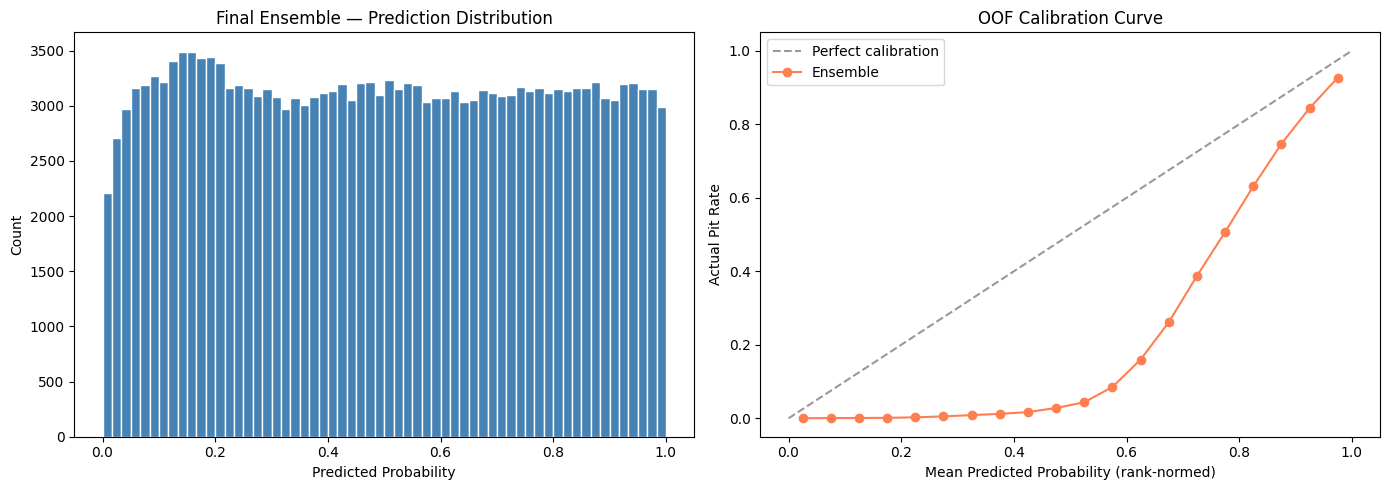


Submission saved to /kaggle/working/submission.csv


In [26]:
test_fe_copy = test_fe[["id"]].copy()
test_fe_copy["PitNextLap"] = final_preds
sub = test_fe_copy.sort_values("id").reset_index(drop=True)
sub.to_csv("/kaggle/working/submission.csv", index=False)

print(f"\nSubmission Stats")
print(f"  Shape         : {sub.shape}")
print(f"  Pred min      : {final_preds.min():.5f}")
print(f"  Pred max      : {final_preds.max():.5f}")
print(f"  Pred mean     : {final_preds.mean():.5f}")

print(f"\nFinal Model Summary")
summary = pd.DataFrame({
    "Model"   : ["LightGBM", "XGBoost", "CatBoost", "Ensemble (optimal)", "Ensemble (equal)"],
    "OOF AUC" : [oof_auc_lgb, oof_auc_xgb, oof_auc_cb, best_auc, equal_auc],
    "Weight"  : [w_lgb_opt, w_xgb_opt, w_cb_opt, "—", "—"],
})
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(final_preds, bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Final Ensemble — Prediction Distribution")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Count")

bins      = np.linspace(0, 1, 21)
bin_idx   = np.digitize(rank_norm(
    w_lgb_opt * oof_lgb_r + w_xgb_opt * oof_xgb_r + w_cb_opt * oof_cb_r
), bins)
bin_pred  = [rank_norm(w_lgb_opt*oof_lgb_r + w_xgb_opt*oof_xgb_r + w_cb_opt*oof_cb_r
                       )[bin_idx==i].mean() for i in range(1, len(bins))]
bin_actual= [y_arr[bin_idx==i].mean() for i in range(1, len(bins))]

axes[1].plot([0,1],[0,1], "k--", alpha=0.4, label="Perfect calibration")
axes[1].plot(bin_pred, bin_actual, "o-", color="coral", label="Ensemble")
axes[1].set_title("OOF Calibration Curve")
axes[1].set_xlabel("Mean Predicted Probability (rank-normed)")
axes[1].set_ylabel("Actual Pit Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSubmission saved to /kaggle/working/submission.csv")